In [1]:
import torch
from torchvision.datasets import EuroSAT
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = EuroSAT(root='../data', download=True, transform=transform)

In [3]:
print("Number of samples:", len(dataset))
print("Classes:", dataset.classes)

Number of samples: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [27]:
def show_images(dataset, num_images=6):
    fig = plt.figure(figsize=(10,5))
    
    for i in range(num_images):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)
        
        ax = fig.add_subplot(2, 3, i+1)
        ax.imshow(img)
        ax.set_title(dataset.classes[label])
        ax.axis('off')
    
    plt.tight_layout()
    
    # ✅ SAVE HERE
    fig.savefig('../outputs/sample_images.png', dpi=300, bbox_inches='tight')
    
    plt.show()

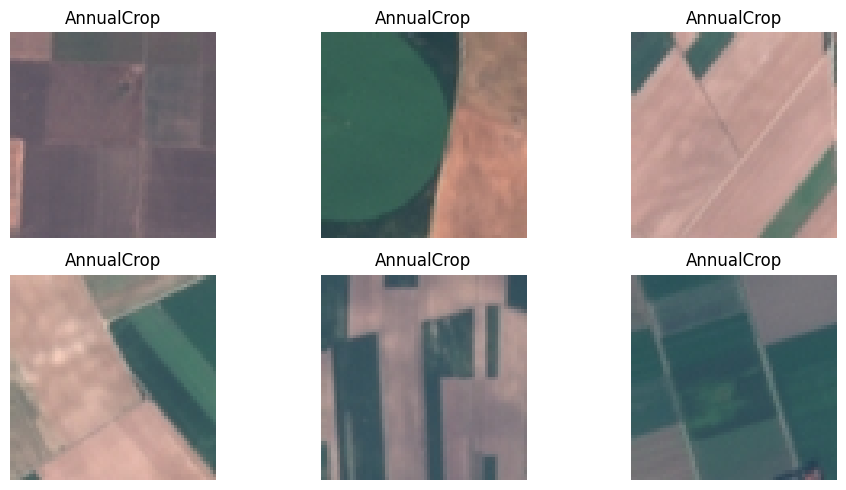

In [28]:
show_images(dataset)

In [6]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [8]:
images, labels = next(iter(train_loader))
print(images.shape)

torch.Size([32, 3, 64, 64])


In [9]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 64 → 32
        x = self.pool(F.relu(self.conv2(x)))  # 32 → 16

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [10]:
#Instantiate Model
model = SimpleCNN(num_classes=len(dataset.classes))
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [11]:
#Loss + Optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [12]:
#Device (important habit)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Using device:", device)

Using device: cpu


In [13]:
#Training loop
from tqdm import tqdm

epochs = 3  # keep small for now

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

100%|████████████████████████████████████████████████████████████████████████████████████| 675/675 [00:28<00:00, 23.48it/s]


Epoch 1, Loss: 825.3419


100%|████████████████████████████████████████████████████████████████████████████████████| 675/675 [00:26<00:00, 25.15it/s]


Epoch 2, Loss: 549.6926


100%|████████████████████████████████████████████████████████████████████████████████████| 675/675 [00:26<00:00, 25.76it/s]

Epoch 3, Loss: 461.5769


In [14]:
#Evaluating model
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 77.78%


In [23]:
# Getting Sample Predictions
def show_predictions(model, dataset, num_images=6):
    model.eval()
    
    plt.figure(figsize=(10,5))
    
    for i in range(num_images):
        img, label = dataset[i]
        
        input_img = img.unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_img)
            _, pred = torch.max(output, 1)
        
        img_np = img.permute(1, 2, 0)
        
        plt.subplot(2, 3, i+1)
        plt.imshow(img_np)
        plt.title(f"True: {dataset.classes[label]}\nPred: {dataset.classes[pred.item()]}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    plt.savefig('../outputs/predictions.png')

In [25]:
def show_predictions(model, dataset, num_images=6):
    model.eval()
    
    fig = plt.figure(figsize=(10,5))
    
    for i in range(num_images):
        img, label = dataset[i]
        input_img = img.unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_img)
            _, pred = torch.max(output, 1)
        
        img_np = img.permute(1, 2, 0)
        
        ax = fig.add_subplot(2, 3, i+1)
        ax.imshow(img_np)
        ax.set_title(f"True: {dataset.classes[label]}\nPred: {dataset.classes[pred.item()]}")
        ax.axis('off')
    
    plt.tight_layout()
    
    # ✅ SAVE HERE (this is the key fix)
    fig.savefig('../outputs/predictions.png', dpi=300, bbox_inches='tight')
    
    plt.show()

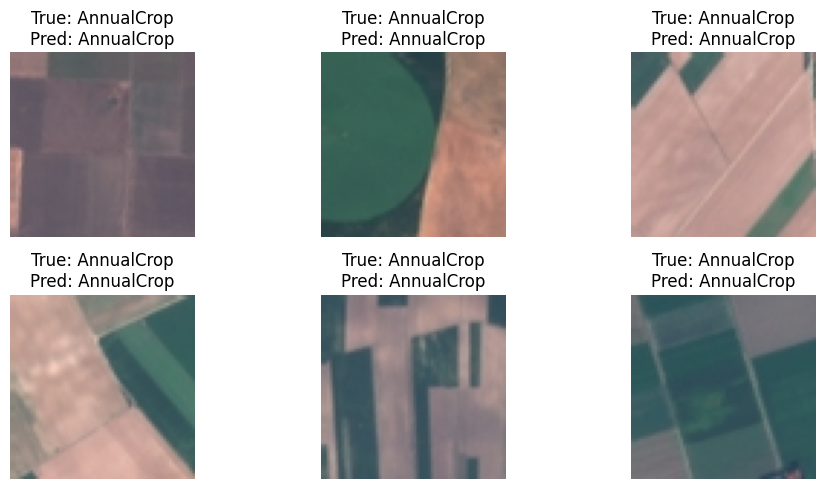

In [26]:
show_predictions(model, dataset)

In [29]:
import random

def show_random_predictions(model, dataset, num_images=12):
    model.eval()
    
    fig = plt.figure(figsize=(12,8))
    
    indices = random.sample(range(len(dataset)), num_images)
    
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        input_img = img.unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_img)
            _, pred = torch.max(output, 1)
        
        img_np = img.permute(1, 2, 0)
        
        ax = fig.add_subplot(3, 4, i+1)
        ax.imshow(img_np)
        ax.set_title(f"T: {dataset.classes[label]}\nP: {dataset.classes[pred.item()]}")
        ax.axis('off')
    
    plt.tight_layout()
    fig.savefig('../outputs/random_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

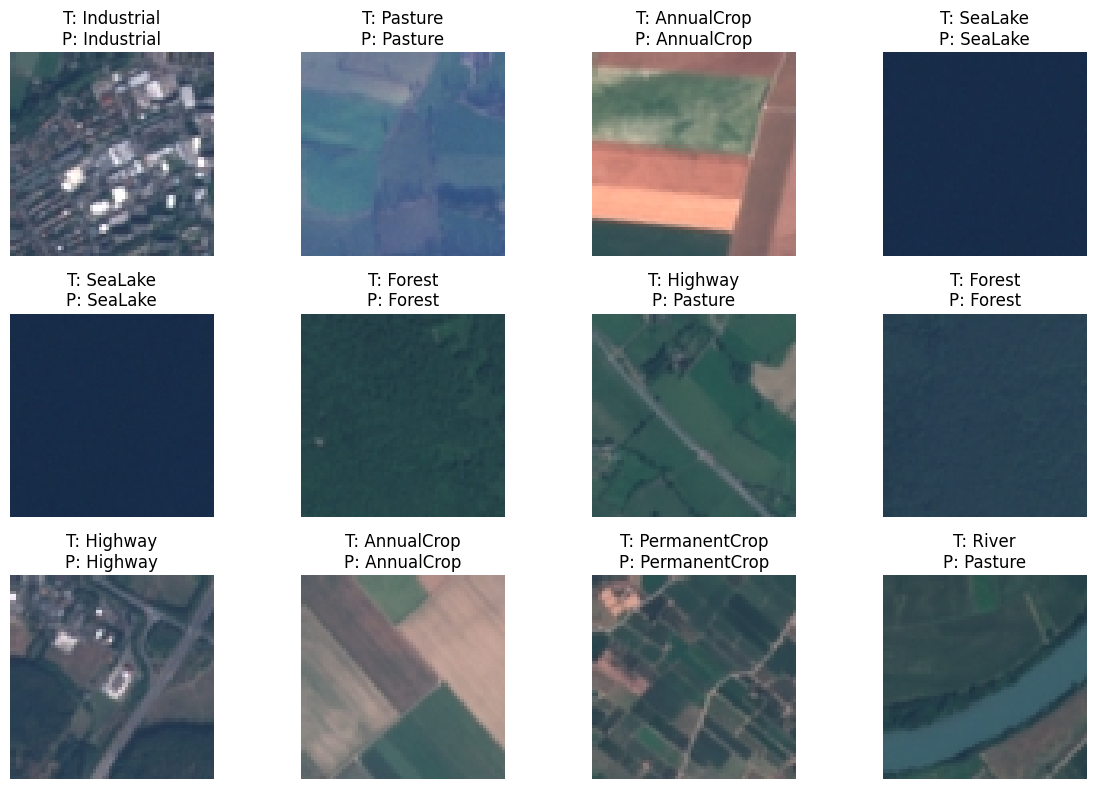

In [30]:
show_random_predictions(model, dataset)

In [32]:
#Wrong predictions
def show_misclassifications(model, dataset, num_images=6):
    model.eval()
    
    fig = plt.figure(figsize=(10,5))
    count = 0
    
    for i in range(len(dataset)):
        img, label = dataset[i]
        input_img = img.unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_img)
            _, pred = torch.max(output, 1)
        
        if pred.item() != label:
            img_np = img.permute(1, 2, 0)
            
            ax = fig.add_subplot(2, 3, count+1)
            ax.imshow(img_np)
            ax.set_title(f"T: {dataset.classes[label]}\nP: {dataset.classes[pred.item()]}")
            ax.axis('off')
            
            count += 1
        
        if count == num_images:
            break
    
    plt.tight_layout()
    fig.savefig('../outputs/misclassifications.png', dpi=300, bbox_inches='tight')
    plt.show()

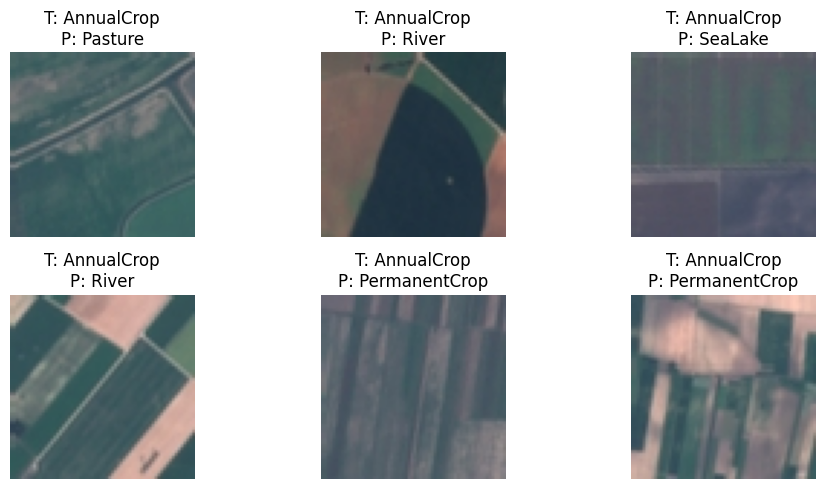

In [33]:
show_misclassifications(model, dataset)

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, test_loader):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    
    fig, ax = plt.subplots(figsize=(8,8))
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, xticks_rotation=45)
    
    fig.savefig('../outputs/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

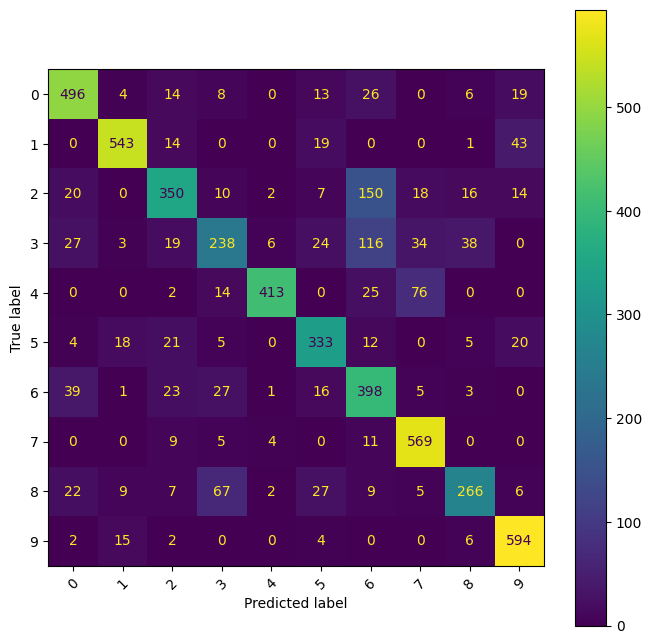

In [35]:
plot_confusion_matrix(model, test_loader)

In [36]:
from sklearn.metrics import classification_report

def get_classification_metrics(model, test_loader, classes):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    report = classification_report(all_labels, all_preds, target_names=classes)
    print(report)

In [37]:
get_classification_metrics(model, test_loader, dataset.classes)

                      precision    recall  f1-score   support

          AnnualCrop       0.81      0.85      0.83       586
              Forest       0.92      0.88      0.90       620
HerbaceousVegetation       0.76      0.60      0.67       587
             Highway       0.64      0.47      0.54       505
          Industrial       0.96      0.78      0.86       530
             Pasture       0.75      0.80      0.77       418
       PermanentCrop       0.53      0.78      0.63       513
         Residential       0.80      0.95      0.87       598
               River       0.78      0.63      0.70       420
             SeaLake       0.85      0.95      0.90       623

            accuracy                           0.78      5400
           macro avg       0.78      0.77      0.77      5400
        weighted avg       0.79      0.78      0.78      5400

